## Customer behavior analysis, campaign effectiveness, and data-driven decision-making

## Load Libraries

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Load Dataset

In [116]:
df = pd.read_csv("Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv")
df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  object 
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  object 
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  object 
 8   segment          64000 non-null  object 
 9   visit            64000 non-null  int64  
 10  conversion       64000 non-null  int64  
 11  spend            64000 non-null  float64
dtypes: float64(2), int64(6), object(4)
memory usage: 5.9+ MB


In [118]:
df.describe()

,recency,history,mens,womens,newbie,visit,conversion,spend
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,5.763734,242.085656,0.551031,0.549719,0.502250,0.146781,0.009031,1.050908
std,3.507592,256.158608,0.497393,0.497526,0.499999,0.353890,0.094604,15.036448
min,1.000000,29.990000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,64.660000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,158.110000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,9.000000,325.657500,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,12.000000,3345.930000,1.000000,1.000000,1.000000,1.000000,1.000000,499.000000


In [119]:
print(f'Rows: {df.shape[0]}\nColumns: {df.shape[1]}')

Rows: 64000
Columns: 12


### This dataset doesn't have null values

In [120]:
df.isna().sum()

recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
segment            0
visit              0
conversion         0
spend              0
dtype: int64

In [121]:
print(f'duplicate rows: {df.duplicated().sum()}')

duplicate rows: 6562


### There is no customer id, so the duplicates can be actual data and we don't drop them

In [122]:
# df.drop_duplicates(inplace=True)

In [123]:
np.sort(df["recency"].unique())

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int64)

In [124]:
overview = pd.DataFrame({"type": df.dtypes, "unique values": df.nunique()})
overview

,type,unique values
recency,int64,12
history_segment,object,7
history,float64,34833
mens,int64,2
womens,int64,2
zip_code,object,3
newbie,int64,2
channel,object,3
segment,object,3
visit,int64,2


In [125]:
df = df.astype({"recency": "Int8", "mens": "Int8", "womens": "Int8", "newbie": "Int8", "visit": "Int8", "conversion": "Int8"})

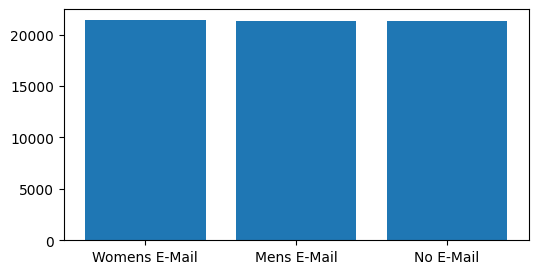

In [126]:
plt.figure(figsize=(6,3))
segment = df["segment"].value_counts()
plt.bar(segment.index, segment)
plt.show()

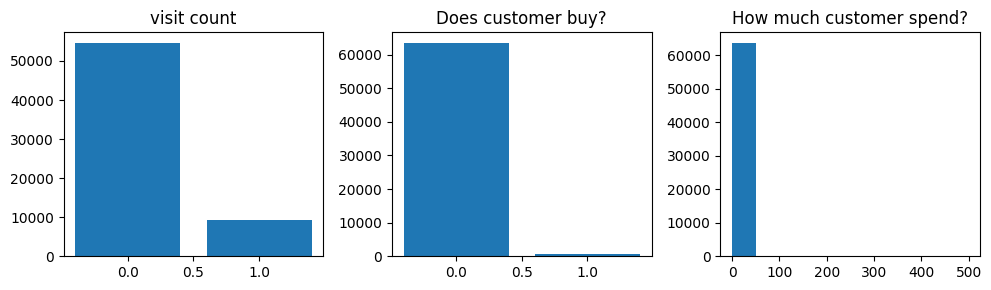

In [127]:
fig, ax = plt.subplots(1,3, figsize=(10,3))
visit = df["visit"].value_counts()
ax[0].bar(visit.index , visit)
ax[0].title.set_text("visit count")

con = df["conversion"].value_counts()
ax[1].bar(con.index, con)
ax[1].title.set_text("Does customer buy?")

ax[2].hist(df["spend"])
ax[2].set_title("How much customer spend?")

plt.tight_layout()
plt.show()

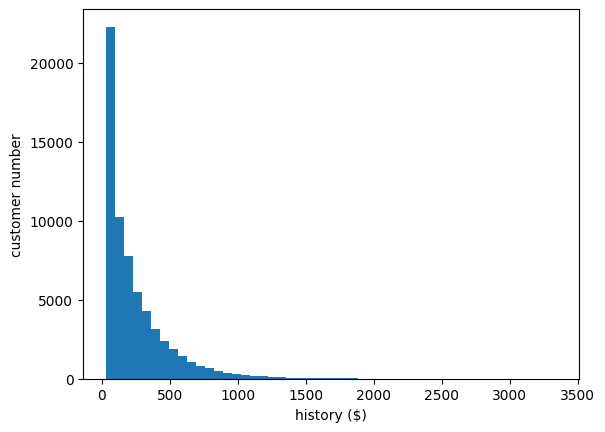

In [128]:
plt.hist(df["history"], bins=50)
plt.xlabel("history ($)"); plt.ylabel("customer number")
plt.show()

In [129]:
df.iloc[10]

recency                         7
history_segment    5) $500 - $750
history                    548.91
mens                            0
womens                          1
zip_code                    Urban
newbie                          1
channel                     Phone
segment             Womens E-Mail
visit                           1
conversion                      0
spend                         0.0
Name: 10, dtype: object

In [130]:
df["history_segment"] = df["history_segment"].str.replace(r'^\d+\)\s*|\$', '', regex=True)

In [131]:
df.head(10)

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,100 - 200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,200 - 350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,100 - 200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,500 - 750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,0 - 100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0
5,6,100 - 200,134.83,0,1,Surburban,0,Phone,Womens E-Mail,1,0,0.0
6,9,200 - 350,280.20,1,0,Surburban,1,Phone,Womens E-Mail,0,0,0.0
7,9,0 - 100,46.42,0,1,Urban,0,Phone,Womens E-Mail,0,0,0.0
8,9,500 - 750,675.07,1,1,Rural,1,Phone,Mens E-Mail,0,0,0.0
9,10,0 - 100,32.84,0,1,Urban,1,Web,Womens E-Mail,0,0,0.0


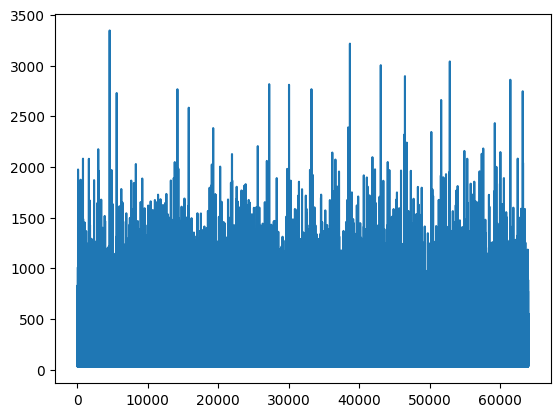

In [132]:
plt.plot(df["history"])
plt.show()